In [ ]:
from featuregraph_smoothing_core.behaviors.oscillation import OscillationConfig
from featuregraph_smoothing_core.datasets import wearable_hr  # confirm this is the actual exported name
import featuregraph_smoothing_core as fg

# Not a validated window -- chosen for demo/compatibility purposes only.
# Real period is irregular for this signal; see the ACF check from earlier.
SMOOTH_WINDOW = 100

hr = wearable_hr(subject="S01")  # confirm the real keyword arg name/subject id

config = OscillationConfig(signal="heart_rate_bpm", smooth_window=SMOOTH_WINDOW)
added = config.add_primitives(hr, "subject")
summary = config.summarize(added, ["subject", config.trough_event_id_col]).reset_index()

print(f"{len(summary)} objects")
summary.head()

9 objects


,subject,heart_rate_bpm_trough_event_id,start_index,rising_duration,falling_duration,peak_index,trough_index,max_raw_signal,max_smooth_signal,min_raw_signal,...,is_complete,duration,period,amplitude_raw,amplitude_smooth,raw_rising_mean_rate,raw_falling_mean_rate,smooth_rising_mean_rate,smooth_falling_mean_rate,temporal_symmetry
0,S01,0,NaN,0,239,NaN,NaN,108.67,86.64200,54.80,...,False,239,NaN,26.935,13.503300,NaN,0.225397,NaN,0.112998,0.000000
1,S01,1,340.0,189,81,529.0,340.0,75.07,69.66195,57.38,...,True,270,NaN,8.845,5.012875,0.093598,0.218395,0.053046,0.123775,0.600000
2,S01,2,610.0,100,161,710.0,610.0,76.57,72.23030,52.32,...,True,261,181.0,12.125,9.583375,0.242500,0.150621,0.191667,0.119048,0.766284
3,S01,3,871.0,135,124,1006.0,871.0,80.62,67.62820,49.37,...,True,259,296.0,15.625,8.475675,0.231481,0.252016,0.125566,0.136704,0.957529
4,S01,4,1130.0,206,28,1336.0,1130.0,62.83,58.74810,50.03,...,True,234,330.0,6.400,4.035375,0.062136,0.457143,0.039178,0.288241,0.239316


(<Figure size 1600x440 with 2 Axes>,
 array([<Axes: ylabel='seconds_from_start'>,
        <Axes: xlabel='Time', ylabel='heart_rate_bpm'>], dtype=object))

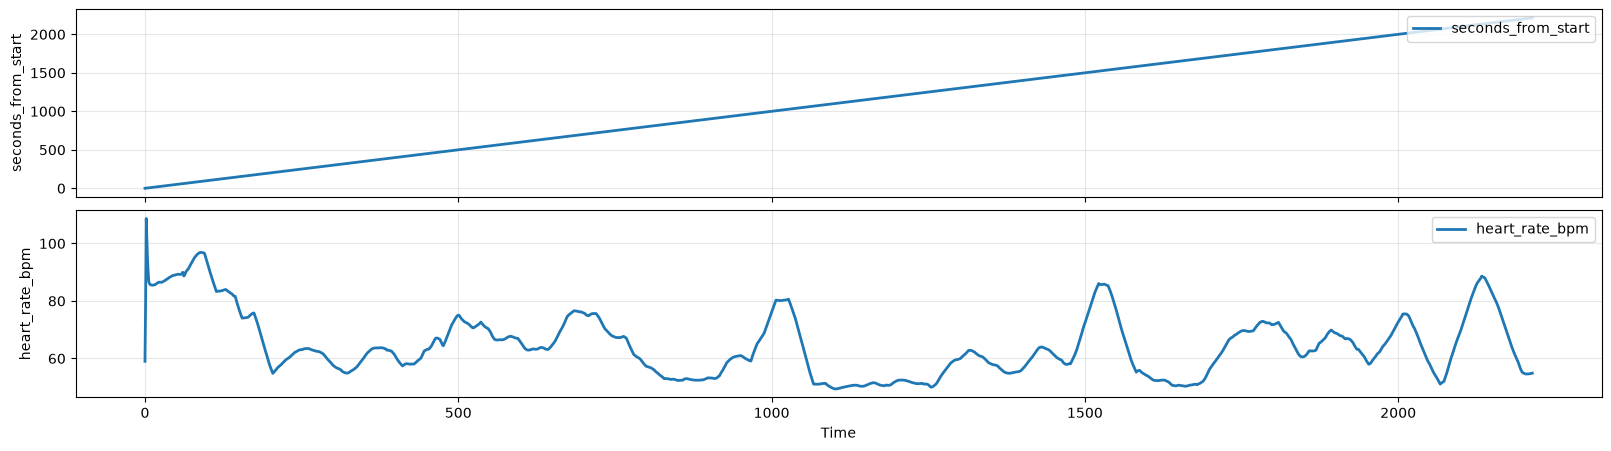

In [10]:
fg.plot(hr, [
                ['seconds_from_start'],
                ['heart_rate_bpm'],
            ]
)

In [11]:
added

,seconds_from_start,timestamp_utc,heart_rate_bpm,subject,heart_rate_bpm_smooth,heart_rate_bpm_rising,heart_rate_bpm_falling,exit_heart_rate_bpm_rising,enter_heart_rate_bpm_rising,heart_rate_bpm_peak_event_id,heart_rate_bpm_trough_event_id,heart_rate_bpm_peak_index,heart_rate_bpm_trough_index
0,0.0,1.361383e+09,59.00,S01,NaN,False,False,False,False,0,0,NaN,NaN
1,1.0,1.361383e+09,79.50,S01,NaN,False,False,False,False,0,0,NaN,NaN
2,2.0,1.361383e+09,108.67,S01,NaN,False,False,False,False,0,0,NaN,NaN
3,3.0,1.361383e+09,101.25,S01,NaN,False,False,False,False,0,0,NaN,NaN
4,4.0,1.361383e+09,94.80,S01,NaN,False,False,False,False,0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2210,2210.0,1.361385e+09,54.67,S01,NaN,False,False,False,False,8,8,2117.0,2046.0
2211,2211.0,1.361385e+09,54.70,S01,NaN,False,False,False,False,8,8,2117.0,2046.0
2212,2212.0,1.361385e+09,54.75,S01,NaN,False,False,False,False,8,8,2117.0,2046.0
2213,2213.0,1.361385e+09,54.82,S01,NaN,False,False,False,False,8,8,2117.0,2046.0


(<Figure size 1600x660 with 3 Axes>,
 array([<Axes: ylabel='heart_rate_bpm'>,
        <Axes: ylabel='heart_rate_bpm_smooth'>,
        <Axes: xlabel='Time', ylabel='exit_heart_rate_bpm_rising'>],
       dtype=object))

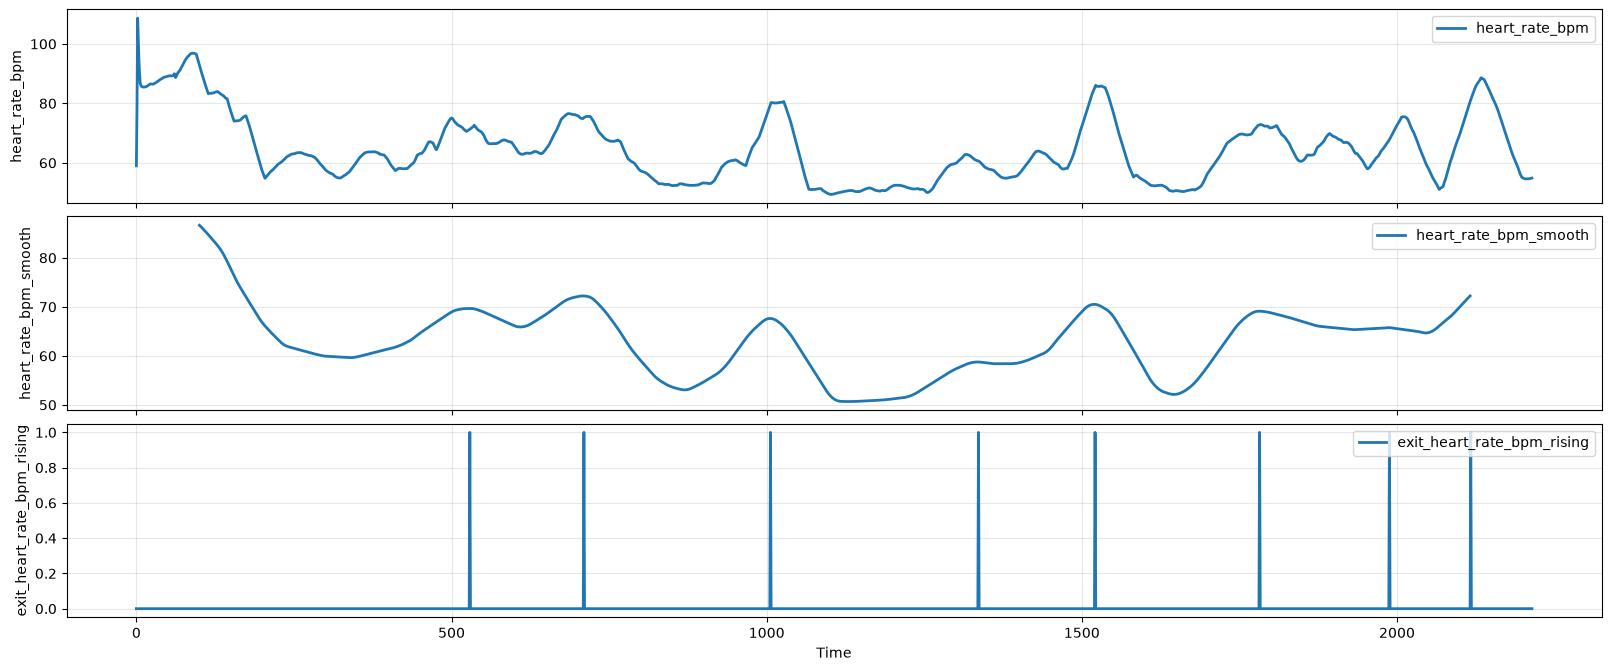

In [12]:
fg.plot(added, [
                ['heart_rate_bpm'],
                ['heart_rate_bpm_smooth'],
                ['exit_heart_rate_bpm_rising']
            ]
)